#### **Algorithm : Bernoulli Naive Bayes**

##### **Project :** 
- SMS Spam Detection**

##### **Problem Statement :**
 - Detect spam messages based on keyword presence.

In [70]:
# Import required Library
# Import Numerical Library
import numpy as np 

# Import Data Manipulation and Cleaning Library 
import pandas as pd 

# Import Data Visualization library 
import matplotlib.pyplot as plt 

# Import Advanced Visualization Library 
import seaborn as sns 

# Import train test split 
from sklearn.model_selection import train_test_split

# Import Count Vectorizer 
from sklearn.feature_extraction.text import CountVectorizer

# Import Bernoulli Naive Bayes 
from sklearn.naive_bayes import BernoulliNB

# Import Evaluation Metrics 
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [71]:
# Step No 2 : Loading Dataset 
df = pd.read_csv("SMS_Spam_Dataset.csv")

In [72]:
# Step No : 3 Data Understanding 

# Display first five rows 
print(df.head())

# Display dataset Shape 
print("\nDataset Shape : ")
print(df.shape)

# Display Column Names 
print("\nColumn Names : ")
print(df.columns.tolist())

# Display dataset information 
print("\nDataset Information : ")
print(df.info())

# Display Statistical information 
print("\nStatistical Summary : ")
print(df.describe(include="all"))

  target                                               text
0   spam  Congratulations! You've been selected for a lu...
1   spam  URGENT: Your account has been compromised. Cli...
2   spam  You've won a free iPhone! Claim your prize by ...
3   spam  Act now and receive a 50% discount on all purc...
4   spam  Important notice: Your subscription will expir...

Dataset Shape : 
(10961, 2)

Column Names : 
['target', 'text']

Dataset Information : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10961 entries, 0 to 10960
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   target  10961 non-null  object
 1   text    10961 non-null  object
dtypes: object(2)
memory usage: 171.4+ KB
None

Statistical Summary : 
       target                    text
count   10961                   10961
unique      2                   10286
top       ham  Sorry, I'll call later
freq     8555                      30


In [73]:
# Step No 4 : Dataset Cleaning 
# Check Missing Values 
print("\nMissing Values : ")
print(df.isnull().sum())

# Check Duplicate Rows 
print("\nDuplicate Values : ")
print(df.duplicated().sum())

# Remove Duplicated values
df = df.drop_duplicates()




Missing Values : 
target    0
text      0
dtype: int64

Duplicate Values : 
674


In [74]:
# Step No 5 : Handling Missing Values 
# Replace missing SMS text with empty string 
df["text"] = df["text"].fillna("")

# Remove rows where target is missing 
df = df.dropna(subset=["target"])

# Display Target Distribution 
# Display spam and ham counts
print("\nTarget Distribution : ")
print(df["target"].value_counts())


Target Distribution : 
target
ham     8014
spam    2273
Name: count, dtype: int64


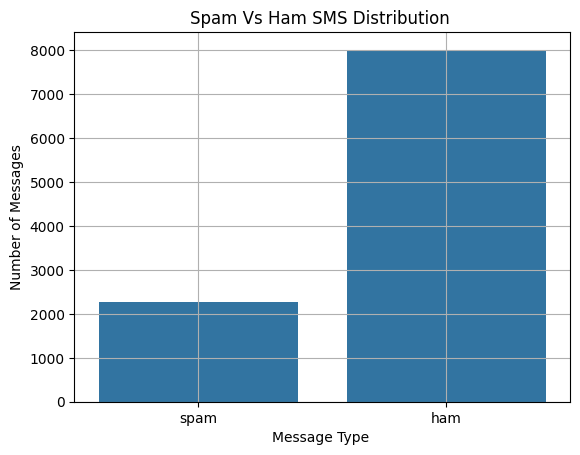

In [75]:
# Step No 6 : Visualize Target Distribution 

# Create Count Plot 
sns.countplot(x = "target", data= df)

# Set Plot title 
plt.title("Spam Vs Ham SMS Distribution ")

# Set x-axis label 
plt.xlabel("Message Type ")

# Set y-axis label 
plt.ylabel("Number of Messages")

# Enable grid 
plt.grid()

# Display Plot 
plt.show()

In [76]:
# Step No 7 : Define Input Feature 

# Define SMS text as input feature 
X = df["text"]

# Define Target Variable 
y = df["target"]

In [77]:
# Step No 8 : Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [78]:
# Step No 9 : Create Binary Count Vectorizer 

# Create CountVectorizer
# binary = True means : 
# Word absent = 0
# Word present = 1  
vectorizer = CountVectorizer(
    lowercase = True , 
    stop_words = "english",
    max_features = 5000,
    binary = True ,
    ngram_range=(1,2)
)

In [79]:
# Step No 10 : Fit and Transform Training Data 

# Learn Vocabulary from training SMS 
# and convert text into binary features 
X_train_vectorized = vectorizer.fit_transform(
    X_train 
)

In [80]:
# Step No 11 : Transform Testing Data 
# Convert testing SMS using 
X_test_vectorized = vectorizer.transform(
    X_test
)

In [81]:
# Step No 12 : Display Vector Shape 
# Display training vector shape 

print("X_train : " , X_train.shape)
print("y_train : " , y_train.shape  )

print("\nTraining Vector Shape : ")
print(X_train_vectorized.shape)

# Display testing vector shape 
print("\nTesting Vector Shape : ")
print(X_test_vectorized.shape)

print("y_test : " , y_test.shape)

X_train :  (8229,)
y_train :  (8229,)

Training Vector Shape : 
(8229, 5000)

Testing Vector Shape : 
(2058, 5000)
y_test :  (2058,)


In [82]:
# Step No 13 : Create Bernoulli Naive Bayes Model 

# Create Bernoulli Naive Bayes Model 
model = BernoulliNB()

In [83]:
# Step No 14 : Train Model 
# Train model using binary word features 
model.fit(X_train_vectorized , 
          y_train)

BernoulliNB()

In [84]:
# Step No 15 : Predict Test Data 

# Predict test SMS messages 
y_pred = model.predict(
    X_test_vectorized
)

# Display Predictions 
print("\nPredicted Values : ")
print(y_pred)


Predicted Values : 
['ham' 'spam' 'ham' ... 'ham' 'ham' 'ham']


In [85]:
# Step No 16 : Evaluate the project metrics 

# Calculate Accuracy 
accuracy = accuracy_score(
    y_test ,
    y_pred
)
# Display accuaracy 
print("\nAccuracy Score : ")
print(accuracy)

# Calculate Classification Report 
print("\nClassification Report : ")
print(
    classification_report(
        y_test , 
        y_pred
    )
)

# Calculate Confusion Matrix 
cm = confusion_matrix(
    y_test , 
    y_pred
)
print("\nConfusion Matrix : ")
print(cm)


Accuracy Score : 
0.9062196307094267

Classification Report : 
              precision    recall  f1-score   support

         ham       0.92      0.97      0.94      1603
        spam       0.86      0.68      0.76       455

    accuracy                           0.91      2058
   macro avg       0.89      0.83      0.85      2058
weighted avg       0.90      0.91      0.90      2058


Confusion Matrix : 
[[1554   49]
 [ 144  311]]


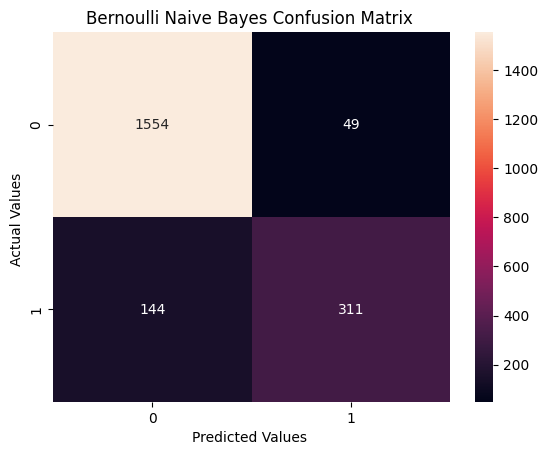

In [86]:
# Step No 17 : Confusion Matrix Heatmap 

# Create Heatmap 
sns.heatmap(
    cm , 

    annot = True ,
    
    fmt = "d"
)

# Set Title 
plt.title("Bernoulli Naive Bayes Confusion Matrix ")

# Set x-axis label 
plt.xlabel("Predicted Values ")

# Set y-axis label 
plt.ylabel("Actual Values ")

# Display Plot 
plt.show()

In [87]:
# Step No 18 : Prediction Probability 

# Calculate prediction probabilities 
probability = model.predict_proba(
    X_test_vectorized
)

# Display first 10 probabilities 
print("\nPrediction Probability : ")
print(probability[:10])


Prediction Probability : 
[[9.99729899e-01 2.70101202e-04]
 [3.54284641e-20 1.00000000e+00]
 [9.99999997e-01 3.41501115e-09]
 [1.00000000e+00 1.49754681e-42]
 [7.54146262e-02 9.24585374e-01]
 [9.99875512e-01 1.24488472e-04]
 [1.00000000e+00 1.20396585e-76]
 [1.00000000e+00 1.77562347e-70]
 [9.17680381e-01 8.23196189e-02]
 [1.00000000e+00 1.68816051e-12]]


In [88]:
# Step No 19 : User Input 

# Take SMS message from user 
user_message = input("\nEnter SMS Message : ")

In [89]:
# Step No 20 : Convert User Message 

# Convert user SMS into binary features 
user_vectorized = vectorizer.transform(
    [user_message]
)

In [90]:
# Step No 21 : Predict User SMS 

# Predict SMS Category 
result = model.predict(
    user_vectorized
)

In [91]:
# Step No 22 : Calculate User Probability 

result_probability = model.predict_proba(
    user_vectorized
)

In [92]:
# Step No 23 : Find Spam Probability 

# Get Model Class Names 
classes = model.classes_

# Find Spam Class Index 
spam_index = list(classes).index("spam")

# Calculate spam probability 
spam_probability = (
    result_probability[0][spam_index] * 100
)

In [93]:
# Step No 26 : Final Output 

print("\n====================================")

print(
    "   SMS SPAM DETECTION "
)

print(
    "   Bernoulli Naive Bayes "
)

print("=======================================")

# Check Prediction 
if result[0] == "spam":
    
    print(
        "Prediction : SPAM MESSAGE"
    )
else:
    
    print(
        "Prediction : HAM / NORMAL MESSAGE"
    )
    
# Display spam probability 
print(
    "Spam Probability : ",
    round(
        spam_probability,
        2
    ),
    "%"
)

print("========================================")


   SMS SPAM DETECTION 
   Bernoulli Naive Bayes 
Prediction : HAM / NORMAL MESSAGE
Spam Probability :  0.0 %
